# Digital Health Twin: Risk Prediction & Time-Series Modeling

Author: Soumya  
Date: April 2026

# Step 1: Synthetic Dataset Creation for a Digital Health Twin Prototype

To support both tabular risk prediction and sequential health trend modeling, I created a synthetic dataset representing 400 patients. Each patient has static demographic/lifestyle attributes and a 48-hour physiological time series. The target variable (`risk`) reflects simplified cardiovascular/metabolic risk based on patterns such as elevated BMI, low activity, increased heart rate, elevated blood pressure, and high glucose level.

In [3]:
import numpy as np
import pandas as pd

np.random.seed(42)

# -----------------------------
# Configuration
# -----------------------------
N_PATIENTS = 400
TIMESTEPS = 48  # 48 hourly observations

patient_rows = []
sequence_rows = []

medical_history_options = ["none", "hypertension", "diabetes", "cardiac_history"]

for patient_id in range(N_PATIENTS):
    # Static patient-level features
    age = np.random.randint(25, 81)
    gender = np.random.choice(["Male", "Female"])
    bmi = np.clip(np.random.normal(26, 4.5), 16, 42)
    activity_level = np.clip(np.random.beta(2, 2), 0, 1)  # 0 = inactive, 1 = highly active
    medical_history = np.random.choice(
        medical_history_options,
        p=[0.40, 0.25, 0.20, 0.15]
    )

    # Medical history effects
    hist_hr_boost = 0
    hist_bp_boost = 0
    hist_glucose_boost = 0

    if medical_history == "hypertension":
        hist_bp_boost = 12
    elif medical_history == "diabetes":
        hist_glucose_boost = 22
    elif medical_history == "cardiac_history":
        hist_hr_boost = 8
        hist_bp_boost = 8

    # Baseline physiological values influenced by static features
    base_hr = 68 + (1 - activity_level) * 14 + (bmi - 25) * 0.8 + hist_hr_boost + (age - 50) * 0.08
    base_bp = 118 + (bmi - 25) * 1.2 + hist_bp_boost + (age - 50) * 0.25
    base_glucose = 92 + (bmi - 25) * 1.8 + hist_glucose_boost + (age - 50) * 0.12

    # Sleep quality proxy: lower for inactive / high BMI patients
    avg_sleep = np.clip(np.random.normal(7.0 - (1 - activity_level) * 1.2 - max(bmi - 28, 0) * 0.05, 0.7), 4.0, 9.0)

    heart_rates = []
    systolic_bps = []
    glucose_levels = []
    sleep_hours = []

    # 48-hour sequence
    for t in range(TIMESTEPS):
        circadian = 3 * np.sin(2 * np.pi * t / 24)  # daily rhythm
        fatigue_effect = (7 - avg_sleep) * 1.5

        hr_t = np.random.normal(base_hr + circadian + fatigue_effect * 0.3, 4)
        bp_t = np.random.normal(base_bp + circadian * 0.7, 6)
        glucose_t = np.random.normal(base_glucose + fatigue_effect * 1.2, 8)
        sleep_t = np.clip(np.random.normal(avg_sleep, 0.4), 3.5, 9.5)

        heart_rates.append(hr_t)
        systolic_bps.append(bp_t)
        glucose_levels.append(glucose_t)
        sleep_hours.append(sleep_t)

        sequence_rows.append({
            "patient_id": patient_id,
            "time_step": t,
            "heart_rate": hr_t,
            "systolic_bp": bp_t,
            "glucose_level": glucose_t,
            "sleep_hours": sleep_t
        })

    # Patient-level summary features for baseline models
    hr_mean = np.mean(heart_rates)
    hr_std = np.std(heart_rates)
    bp_mean = np.mean(systolic_bps)
    glucose_mean = np.mean(glucose_levels)
    sleep_mean = np.mean(sleep_hours)

    # Trend over time (simple slope approximation)
    hr_trend = np.polyfit(np.arange(TIMESTEPS), heart_rates, 1)[0]
    glucose_trend = np.polyfit(np.arange(TIMESTEPS), glucose_levels, 1)[0]

    # Risk definition
    risk_score = 0

    if age > 55:
        risk_score += 1
    if bmi > 30:
        risk_score += 1
    if activity_level < 0.35:
        risk_score += 1
    if hr_mean > 82:
        risk_score += 1
    if bp_mean > 135:
        risk_score += 1
    if glucose_mean > 125:
        risk_score += 1
    if medical_history in ["diabetes", "cardiac_history"]:
        risk_score += 1
    if hr_trend > 0.03:
        risk_score += 1

    risk = 1 if risk_score >= 4 else 0

    patient_rows.append({
        "patient_id": patient_id,
        "age": age,
        "gender": gender,
        "bmi": round(bmi, 2),
        "activity_level": round(activity_level, 3),
        "medical_history": medical_history,
        "hr_mean": round(hr_mean, 2),
        "hr_std": round(hr_std, 2),
        "bp_mean": round(bp_mean, 2),
        "glucose_mean": round(glucose_mean, 2),
        "sleep_mean": round(sleep_mean, 2),
        "hr_trend": round(hr_trend, 4),
        "glucose_trend": round(glucose_trend, 4),
        "risk": risk
    })

# Create dataframes
patients_df = pd.DataFrame(patient_rows)
time_series_df = pd.DataFrame(sequence_rows)

print("Patient-level dataset shape:", patients_df.shape)
print("Time-series dataset shape:", time_series_df.shape)

patients_df.head(), time_series_df.head()

Patient-level dataset shape: (400, 14)
Time-series dataset shape: (19200, 6)


(   patient_id  age  gender    bmi  activity_level  medical_history  hr_mean  \
 0           0   63  Female  21.00           0.312  cardiac_history    83.20   
 1           1   26  Female  29.93           0.886         diabetes    72.40   
 2           2   59    Male  25.51           0.488  cardiac_history    84.67   
 3           3   55    Male  31.79           0.289     hypertension    83.54   
 4           4   72  Female  31.08           0.329     hypertension    85.20   
 
    hr_std  bp_mean  glucose_mean  sleep_mean  hr_trend  glucose_trend  risk  
 0    3.57   124.49         85.32        6.72   -0.0456         0.0582     1  
 1    4.16   118.39        122.87        6.10   -0.0951         0.0631     0  
 2    4.59   128.12         94.44        6.37   -0.0777         0.0482     0  
 3    4.18   139.79        108.33        5.35   -0.0434         0.0172     1  
 4    4.12   143.38        108.53        5.75   -0.0578        -0.1430     1  ,
    patient_id  time_step  heart_rate  syst

In [6]:
patients_df.to_csv("synthetic_patient_risk_dataset.csv", index=False)
time_series_df.to_csv("synthetic_patient_timeseries_dataset.csv", index=False)

print("Saved:")
print("- synthetic_patient_risk_dataset.csv")
print("- synthetic_patient_timeseries_dataset.csv")

Saved:
- synthetic_patient_risk_dataset.csv
- synthetic_patient_timeseries_dataset.csv


In [4]:
# Introduce small missingness for realism
for col in ["bmi", "activity_level", "glucose_mean", "sleep_mean"]:
    mask = np.random.rand(len(patients_df)) < 0.04
    patients_df.loc[mask, col] = np.nan

for col in ["heart_rate", "systolic_bp", "glucose_level", "sleep_hours"]:
    mask = np.random.rand(len(time_series_df)) < 0.02
    time_series_df.loc[mask, col] = np.nan

print(patients_df.isnull().sum())
print(time_series_df.isnull().sum())

patient_id          0
age                 0
gender              0
bmi                18
activity_level     17
medical_history     0
hr_mean             0
hr_std              0
bp_mean             0
glucose_mean       13
sleep_mean         15
hr_trend            0
glucose_trend       0
risk                0
dtype: int64
patient_id         0
time_step          0
heart_rate       383
systolic_bp      387
glucose_level    348
sleep_hours      385
dtype: int64


### Observations
The generated dataset contains both patient-level summaries and hourly physiological sequences. This structure enables two complementary modeling approaches:
1. tabular risk prediction using demographic and aggregated health indicators
2. temporal modeling using sequential physiological signals

The target variable was intentionally defined using risk factors that are medically plausible, allowing later model explainability to remain interpretable.

# Step 2: Exploratory Data Analysis (EDA)

This section analyzes the structure, distributions, correlations, and temporal behavior of the dataset. The goal is to understand key patterns, identify potential risk drivers, and prepare the data for modeling.

## 2.1 Basic Data Inspection

I first inspected the patient-level and time-series datasets to verify feature types, target availability, and overall dataset dimensions before performing detailed analysis.

In [8]:
print("Patient-level dataset shape:", patients_df.shape)
print("Time-series dataset shape:", time_series_df.shape)

print("\nPatient-level columns:")
print(patients_df.columns.tolist())

print("\nTime-series columns:")
print(time_series_df.columns.tolist())

print("\nPatient-level info:")
patients_df.info()

print("\nTime-series info:")
time_series_df.info()

print("\nFirst 5 rows of patient-level dataset:")
display(patients_df.head())

print("\nFirst 5 rows of time-series dataset:")
display(time_series_df.head())

Patient-level dataset shape: (400, 14)
Time-series dataset shape: (19200, 6)

Patient-level columns:
['patient_id', 'age', 'gender', 'bmi', 'activity_level', 'medical_history', 'hr_mean', 'hr_std', 'bp_mean', 'glucose_mean', 'sleep_mean', 'hr_trend', 'glucose_trend', 'risk']

Time-series columns:
['patient_id', 'time_step', 'heart_rate', 'systolic_bp', 'glucose_level', 'sleep_hours']

Patient-level info:
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   patient_id       400 non-null    int64  
 1   age              400 non-null    int64  
 2   gender           400 non-null    str    
 3   bmi              400 non-null    float64
 4   activity_level   400 non-null    float64
 5   medical_history  400 non-null    str    
 6   hr_mean          400 non-null    float64
 7   hr_std           400 non-null    float64
 8   bp_mean          400 non-null    

,patient_id,age,gender,bmi,activity_level,medical_history,hr_mean,hr_std,bp_mean,glucose_mean,sleep_mean,hr_trend,glucose_trend,risk
0,0,63,Female,21.00,0.312,cardiac_history,83.20,3.57,124.49,85.32,6.72,-0.0456,0.0582,1
1,1,26,Female,29.93,0.886,diabetes,72.40,4.16,118.39,122.87,6.10,-0.0951,0.0631,0
2,2,59,Male,25.51,0.488,cardiac_history,84.67,4.59,128.12,94.44,6.37,-0.0777,0.0482,0
3,3,55,Male,31.79,0.289,hypertension,83.54,4.18,139.79,108.33,5.35,-0.0434,0.0172,1
4,4,72,Female,31.08,0.329,hypertension,85.20,4.12,143.38,108.53,5.75,-0.0578,-0.1430,1



First 5 rows of time-series dataset:


,patient_id,time_step,heart_rate,systolic_bp,glucose_level,sleep_hours
0,0,0,81.714299,127.701208,83.164530,6.525875
1,0,1,85.336503,113.509686,73.072528,6.487252
2,0,2,81.040872,127.381331,79.607679,6.147245
3,0,3,91.576112,124.576114,87.412097,6.142267
4,0,4,84.012742,126.930036,77.663923,6.862446


## 2.2 Missing Data Analysis

Because healthcare datasets often contain incomplete measurements, I examined missing values in both the static patient-level table and the time-series table.

In [9]:
missing_patients = patients_df.isnull().sum().sort_values(ascending=False)
missing_ts = time_series_df.isnull().sum().sort_values(ascending=False)

print("Missing values in patient-level dataset:")
print(missing_patients)

print("\nMissing values in time-series dataset:")
print(missing_ts)

Missing values in patient-level dataset:
patient_id         0
age                0
gender             0
bmi                0
activity_level     0
medical_history    0
hr_mean            0
hr_std             0
bp_mean            0
glucose_mean       0
sleep_mean         0
hr_trend           0
glucose_trend      0
risk               0
dtype: int64

Missing values in time-series dataset:
patient_id       0
time_step        0
heart_rate       0
systolic_bp      0
glucose_level    0
sleep_hours      0
dtype: int64


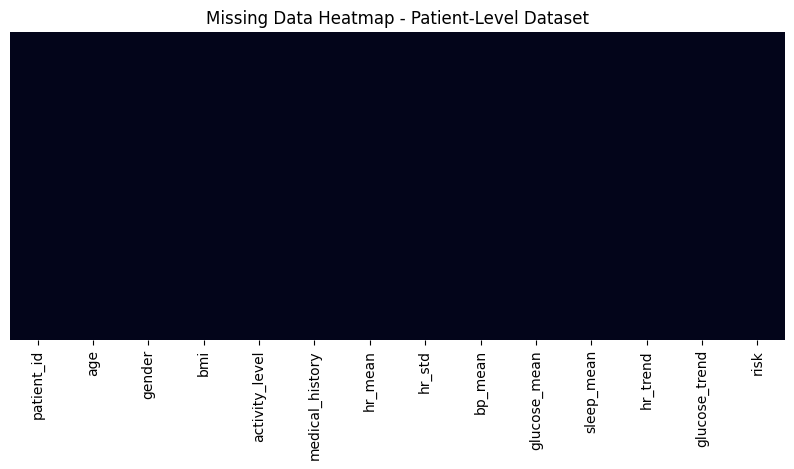

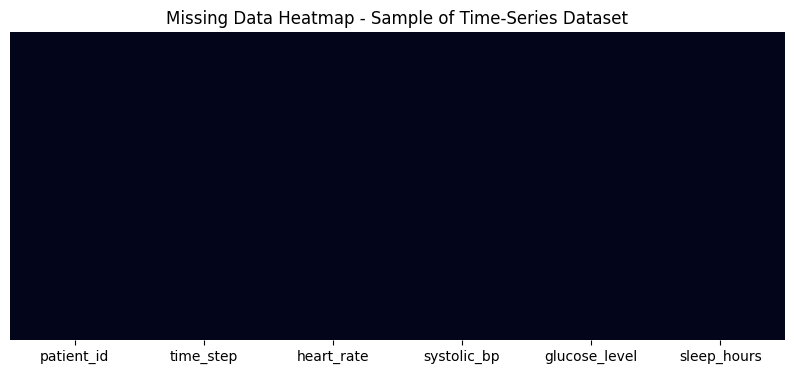

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))
sns.heatmap(patients_df.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Data Heatmap - Patient-Level Dataset")
plt.show()

plt.figure(figsize=(10, 4))
sns.heatmap(time_series_df.isnull().sample(min(1000, len(time_series_df))), cbar=False, yticklabels=False)
plt.title("Missing Data Heatmap - Sample of Time-Series Dataset")
plt.show()

## 2.3 Missing Data Handling

To prepare the data for modeling:

- patient-level numeric missing values were imputed using mean imputation
- time-series missing values were handled using forward fill within each patient sequence

This strategy preserves sequence continuity while keeping preprocessing simple and interpretable.

In [5]:
# Copy to avoid accidental overwrite if needed
patients_df_clean = patients_df.copy()
time_series_df_clean = time_series_df.copy()

# Mean imputation for patient-level numeric features
patient_impute_cols = ["bmi", "activity_level", "glucose_mean", "sleep_mean"]

for col in patient_impute_cols:
    patients_df_clean[col] = patients_df_clean[col].fillna(patients_df_clean[col].mean())

# Forward fill within each patient for time-series columns
time_series_df_clean = time_series_df_clean.sort_values(["patient_id", "time_step"])

ts_cols = ["heart_rate", "systolic_bp", "glucose_level", "sleep_hours"]
time_series_df_clean[ts_cols] = (
    time_series_df_clean.groupby("patient_id")[ts_cols].ffill()
)

# If any missing values remain at the first time step, backfill once
time_series_df_clean[ts_cols] = (
    time_series_df_clean.groupby("patient_id")[ts_cols].bfill()
)

print("Remaining missing values in patient-level dataset:")
print(patients_df_clean.isnull().sum())

print("\nRemaining missing values in time-series dataset:")
print(time_series_df_clean.isnull().sum())

Remaining missing values in patient-level dataset:
patient_id         0
age                0
gender             0
bmi                0
activity_level     0
medical_history    0
hr_mean            0
hr_std             0
bp_mean            0
glucose_mean       0
sleep_mean         0
hr_trend           0
glucose_trend      0
risk               0
dtype: int64

Remaining missing values in time-series dataset:
patient_id       0
time_step        0
heart_rate       0
systolic_bp      0
glucose_level    0
sleep_hours      0
dtype: int64


## 2.4 Target Distribution

The risk label distribution was examined to understand whether the classification problem is balanced or imbalanced.

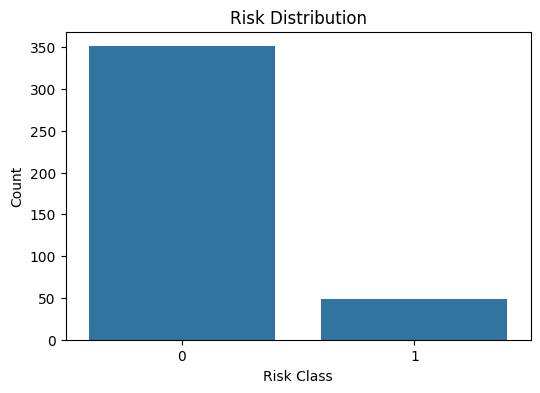

Risk counts:
risk
0    351
1     49
Name: count, dtype: int64

Risk proportions:
risk
0    0.8775
1    0.1225
Name: proportion, dtype: float64


In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(x="risk", data=patients_df_clean)
plt.title("Risk Distribution")
plt.xlabel("Risk Class")
plt.ylabel("Count")
plt.show()

risk_dist = patients_df_clean["risk"].value_counts()
risk_prop = patients_df_clean["risk"].value_counts(normalize=True)

print("Risk counts:")
print(risk_dist)

print("\nRisk proportions:")
print(risk_prop)

### Interpretation

The target variable is moderately imbalanced. Approximately 87.8% of patients belong to the low-risk class, while 12.2% belong to the high-risk class.

This pattern is realistic for healthcare risk screening, where adverse outcomes are often less frequent than non-adverse cases. However, class imbalance may bias predictive models toward the majority class. Therefore, in the modeling stage, I will rely not only on accuracy but also on precision, recall, and ROC-AUC, and I will apply imbalance-aware strategies such as class weighting.

## 2.5 Feature Distributions

I examined the distributions of key static and aggregated physiological features to understand data spread, skewness, and potential separation between healthy and higher-risk profiles.

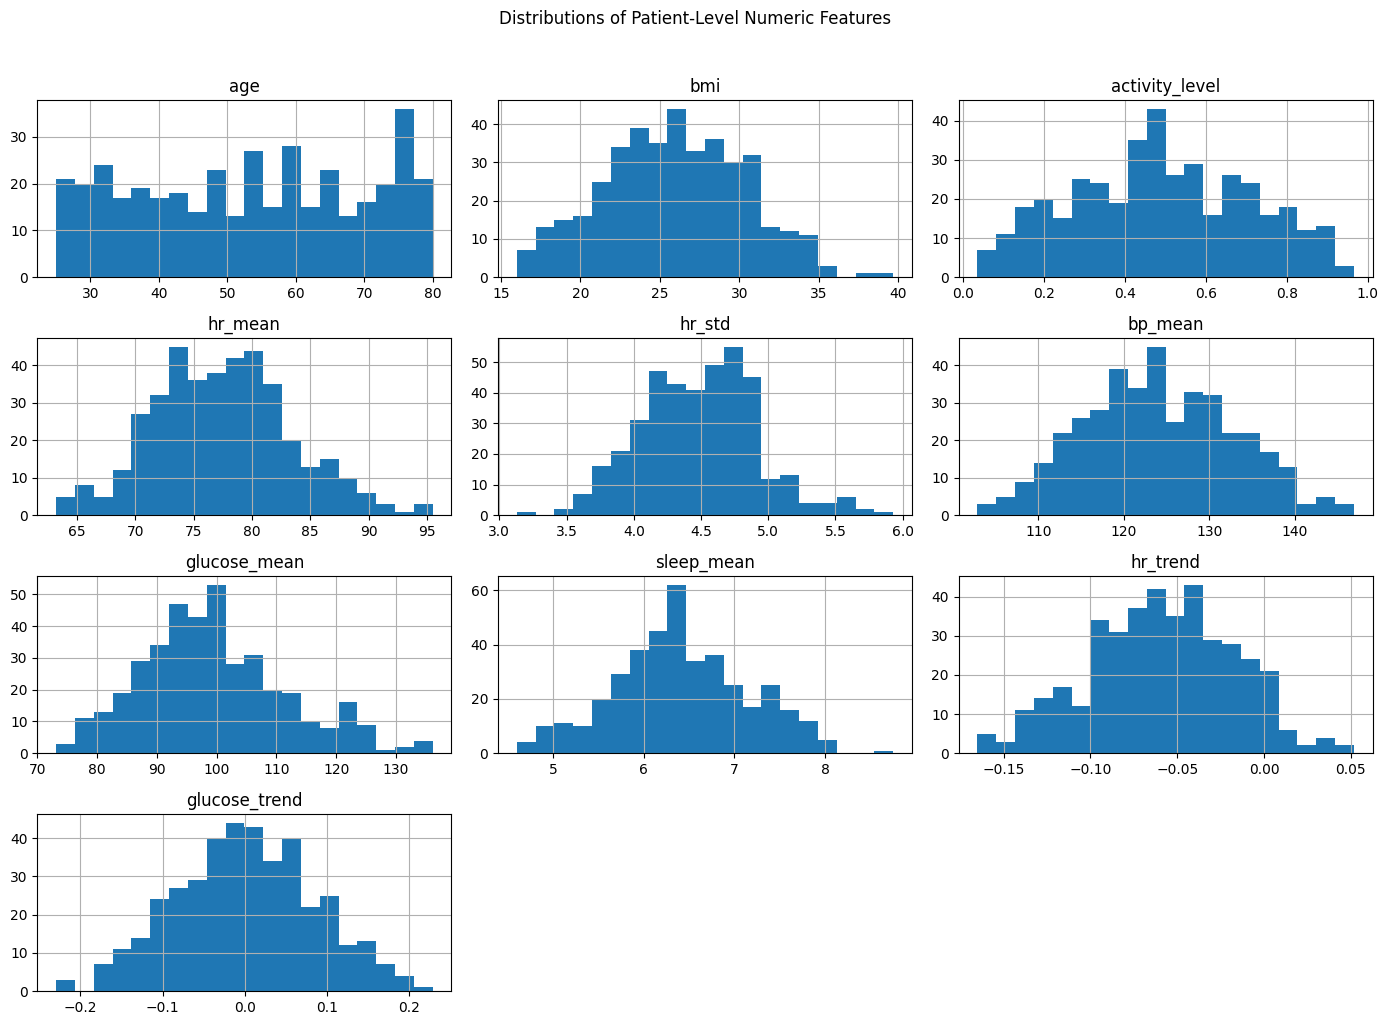

In [13]:
num_cols = [
    "age", "bmi", "activity_level", "hr_mean", "hr_std",
    "bp_mean", "glucose_mean", "sleep_mean", "hr_trend", "glucose_trend"
]

patients_df_clean[num_cols].hist(figsize=(14, 10), bins=20)
plt.suptitle("Distributions of Patient-Level Numeric Features", y=1.02)
plt.tight_layout()
plt.show()

### Interpretation

The feature distributions are generally plausible for a synthetic health dataset:

- age spans adult to elderly patients
- BMI is centered around the mid-20s with some high-BMI patients
- activity level varies across patients, capturing both sedentary and active lifestyles
- heart rate, blood pressure, and glucose summaries show realistic variability

These distributions suggest the dataset contains meaningful heterogeneity for risk modeling.

## 2.6 Correlation Analysis

A correlation matrix was used to identify linear relationships between patient-level numeric variables and the target risk label.

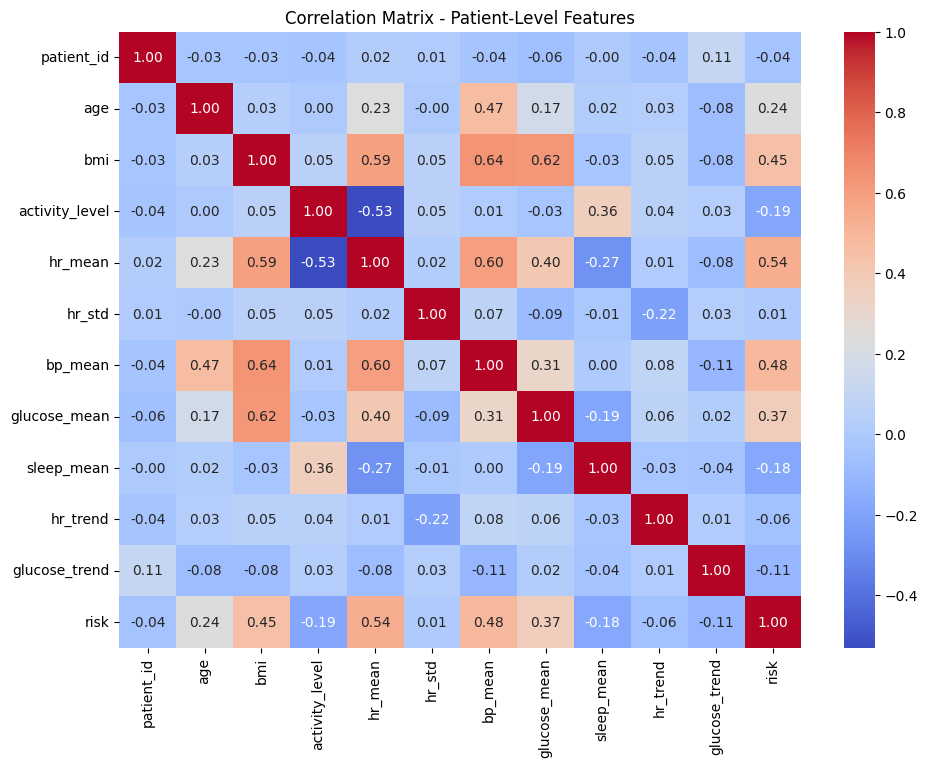

In [14]:
plt.figure(figsize=(11, 8))
corr = patients_df_clean.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix - Patient-Level Features")
plt.show()

### Interpretation

Several expected relationships are visible in the correlation matrix:

- BMI is positively associated with blood pressure and glucose level
- activity level is negatively associated with heart rate and risk
- higher mean heart rate, blood pressure, and glucose tend to align with increased risk
- temporal trend features such as heart rate trend also show association with the target

These patterns are consistent with the intended health-risk logic embedded in the synthetic data generation process.

## 2.7 Risk vs Feature Analysis

To better understand which variables differentiate low-risk and high-risk patients, I compared selected features across the two risk groups.

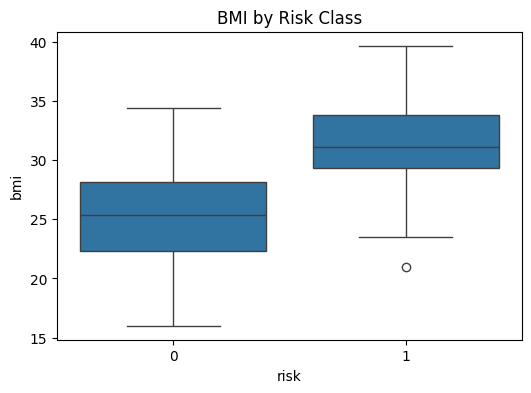

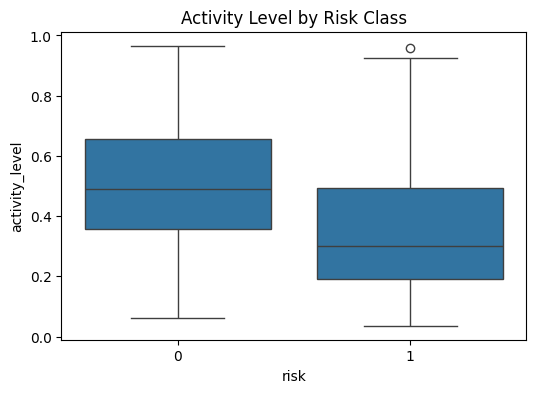

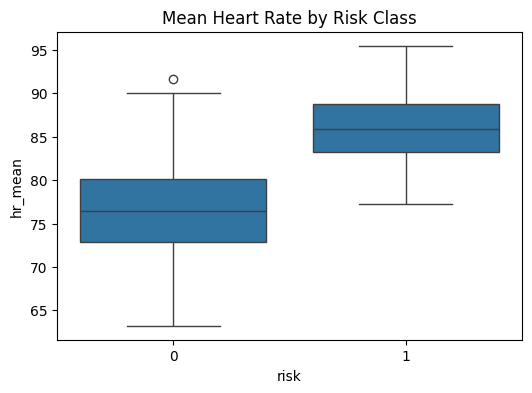

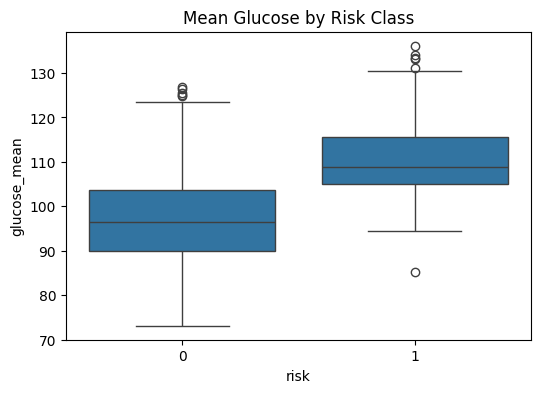

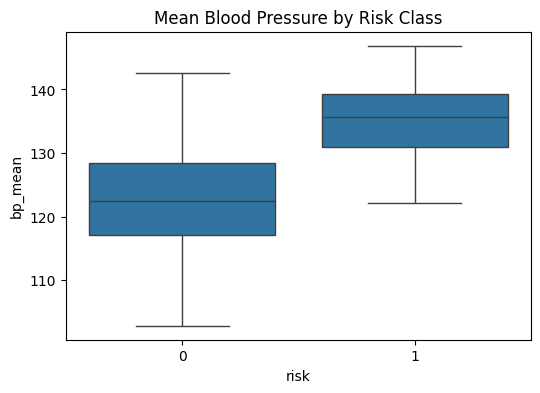

In [15]:
plt.figure(figsize=(6, 4))
sns.boxplot(x="risk", y="bmi", data=patients_df_clean)
plt.title("BMI by Risk Class")
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(x="risk", y="activity_level", data=patients_df_clean)
plt.title("Activity Level by Risk Class")
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(x="risk", y="hr_mean", data=patients_df_clean)
plt.title("Mean Heart Rate by Risk Class")
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(x="risk", y="glucose_mean", data=patients_df_clean)
plt.title("Mean Glucose by Risk Class")
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(x="risk", y="bp_mean", data=patients_df_clean)
plt.title("Mean Blood Pressure by Risk Class")
plt.show()

### Interpretation

High-risk patients tend to show:

- higher BMI
- lower activity levels
- higher mean heart rate
- higher mean glucose
- higher mean blood pressure

This indicates that the target class is meaningfully associated with clinically relevant predictors, which is desirable for both predictive modeling and explainability.

## 2.8 Categorical Feature Analysis

To further understand how pre-existing medical conditions influence risk, I analyzed the relationship between medical history and the risk label.

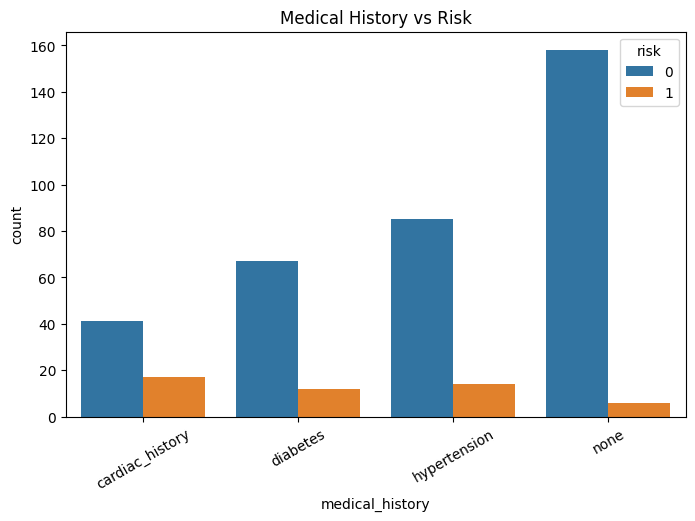

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.countplot(x="medical_history", hue="risk", data=patients_df_clean)
plt.title("Medical History vs Risk")
plt.xticks(rotation=30)
plt.show()

### Interpretation

Patients with pre-existing conditions such as diabetes and cardiac history show a higher proportion of high-risk cases compared to patients with no prior conditions.

This aligns with real-world clinical knowledge, where chronic conditions significantly increase the likelihood of adverse health outcomes. This further validates the structure of the synthetic dataset and supports the relevance of medical history as an important predictive feature.

## 2.9 Time-Series Visualization

To inspect sequential behavior, I visualized physiological measurements over time for an example patient.

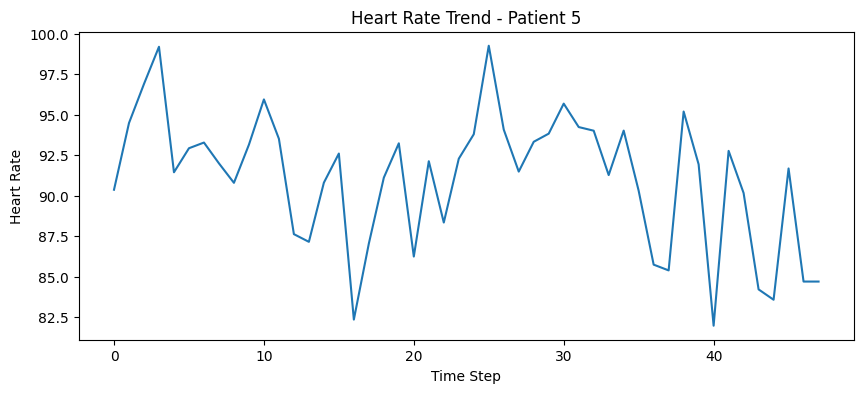

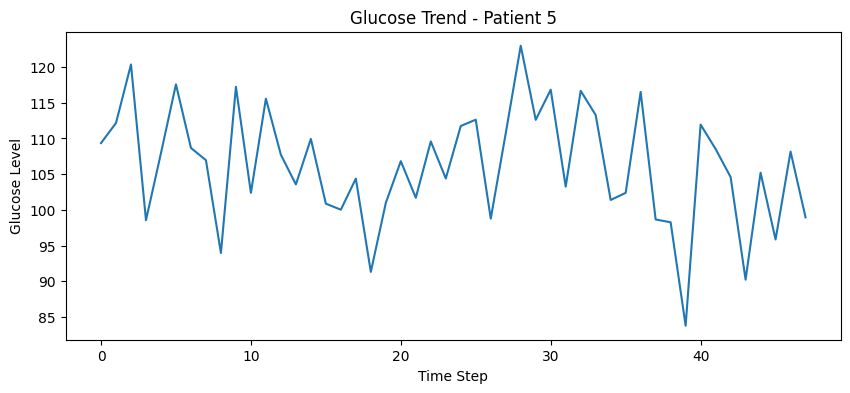

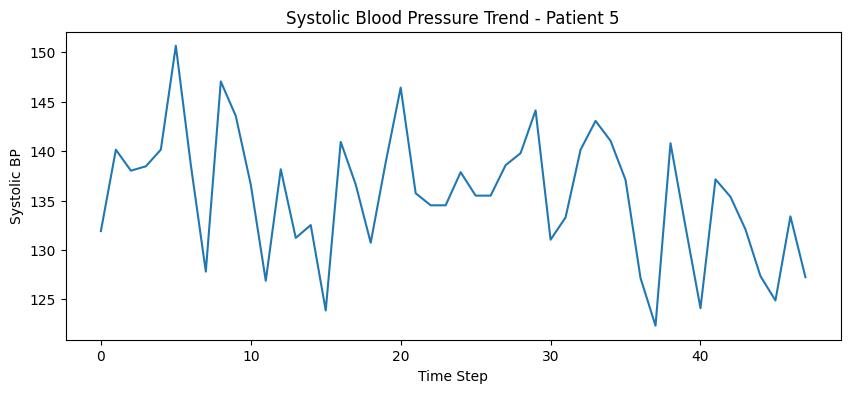

In [16]:
sample_id = 5
sample = time_series_df_clean[time_series_df_clean["patient_id"] == sample_id]

plt.figure(figsize=(10, 4))
plt.plot(sample["time_step"], sample["heart_rate"])
plt.title(f"Heart Rate Trend - Patient {sample_id}")
plt.xlabel("Time Step")
plt.ylabel("Heart Rate")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(sample["time_step"], sample["glucose_level"])
plt.title(f"Glucose Trend - Patient {sample_id}")
plt.xlabel("Time Step")
plt.ylabel("Glucose Level")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(sample["time_step"], sample["systolic_bp"])
plt.title(f"Systolic Blood Pressure Trend - Patient {sample_id}")
plt.xlabel("Time Step")
plt.ylabel("Systolic BP")
plt.show()

### Interpretation

The physiological signals vary over time rather than remaining constant. The observed fluctuations reflect daily variation, latent fatigue effects, and patient-specific baseline health status.

This confirms that the dataset is suitable not only for static classification but also for sequential modeling approaches such as rolling-window analysis or LSTM-based prediction.

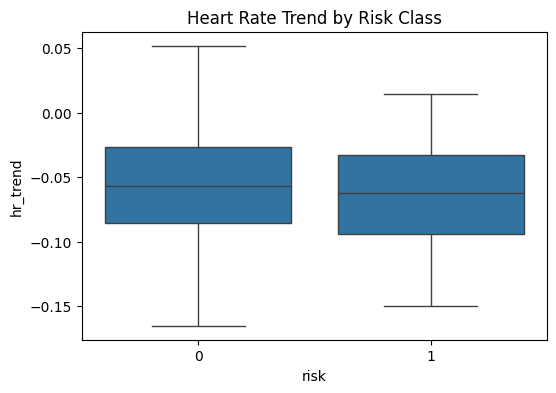

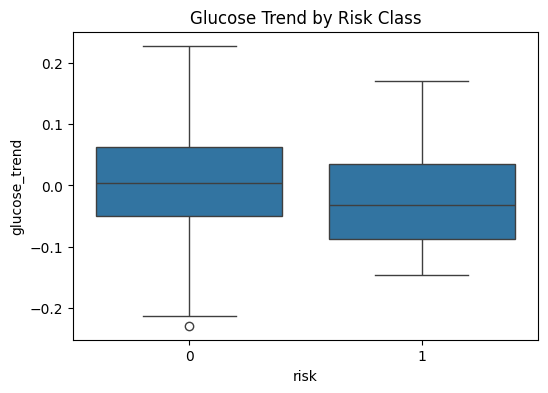

In [17]:
plt.figure(figsize=(6, 4))
sns.boxplot(x="risk", y="hr_trend", data=patients_df_clean)
plt.title("Heart Rate Trend by Risk Class")
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(x="risk", y="glucose_trend", data=patients_df_clean)
plt.title("Glucose Trend by Risk Class")
plt.show()

### Interpretation

Patients in the high-risk group tend to exhibit less favorable temporal trends, particularly in heart rate and glucose progression. This supports the inclusion of time-dependent information in later modeling stages.

## 2.10 EDA Summary

The exploratory analysis produced several important findings:

- the dataset contains realistic variation across demographic, lifestyle, and physiological features
- high-risk patients are less frequent than low-risk patients, producing a moderately imbalanced classification task
- higher BMI, lower activity, elevated heart rate, elevated blood pressure, and elevated glucose are associated with higher risk
- the time-series signals show meaningful temporal variation, supporting sequential modeling

These observations guide the next stage of the pipeline. In particular, the class imbalance motivates the use of recall and ROC-AUC in addition to accuracy, while the temporal structure motivates later use of time-series modeling.

In [6]:
patients_df = patients_df_clean.copy()
time_series_df = time_series_df_clean.copy()

## 2.11 Final Preprocessed Dataset

After handling missing values and completing exploratory analysis, the cleaned datasets are finalized for use in subsequent modeling steps.

# Step 3: Risk Prediction Modeling

This section focuses on building predictive models to classify patient risk. A baseline model (Logistic Regression) and an advanced model (XGBoost) are implemented and compared using multiple evaluation metrics.

## 3.1 Feature Preparation

Before training models, categorical variables are encoded and features are separated from the target variable.

In [7]:
from sklearn.preprocessing import LabelEncoder

df_model = patients_df.copy()

# Encode categorical variables
le_gender = LabelEncoder()
le_history = LabelEncoder()

df_model["gender"] = le_gender.fit_transform(df_model["gender"])
df_model["medical_history"] = le_history.fit_transform(df_model["medical_history"])

# Features and target
X = df_model.drop(columns=["risk", "patient_id"])
y = df_model["risk"]

print(X.shape, y.shape)

(400, 12) (400,)


## 3.2 Train-Test Split

The dataset is split into training and testing sets (80/20). Stratified sampling is used to preserve class imbalance distribution.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## 3.3 Handling Class Imbalance

Due to the imbalance in the dataset, class weighting is applied to ensure the model gives appropriate importance to high-risk patients.

In [9]:
# Calculate class weight ratio for XGBoost
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 7.205128205128205


## 3.4 Baseline Model: Logistic Regression

A Logistic Regression model is used as a baseline due to its simplicity and interpretability. Class weights are used to address imbalance.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

log_model = LogisticRegression(class_weight="balanced", max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

In [9]:
log_acc = accuracy_score(y_test, y_pred_log)
log_prec = precision_score(y_test, y_pred_log)
log_rec = recall_score(y_test, y_pred_log)
log_auc = roc_auc_score(y_test, y_prob_log)

print("Logistic Regression Performance:")
print("Accuracy:", log_acc)
print("Precision:", log_prec)
print("Recall:", log_rec)
print("ROC-AUC:", log_auc)

Logistic Regression Performance:
Accuracy: 0.9625
Precision: 0.8888888888888888
Recall: 0.8
ROC-AUC: 0.9685714285714285


## 3.5 Advanced Model: XGBoost

XGBoost is used as an advanced model due to its ability to capture non-linear relationships and interactions between features.

In [10]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [11]:
xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_prec = precision_score(y_test, y_pred_xgb)
xgb_rec = recall_score(y_test, y_pred_xgb)
xgb_auc = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost Performance:")
print("Accuracy:", xgb_acc)
print("Precision:", xgb_prec)
print("Recall:", xgb_rec)
print("ROC-AUC:", xgb_auc)

XGBoost Performance:
Accuracy: 0.9625
Precision: 0.8888888888888888
Recall: 0.8
ROC-AUC: 0.9957142857142858


In [12]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost"],
    "Accuracy": [log_acc, xgb_acc],
    "Precision": [log_prec, xgb_prec],
    "Recall": [log_rec, xgb_rec],
    "ROC-AUC": [log_auc, xgb_auc]
})

results

,Model,Accuracy,Precision,Recall,ROC-AUC
0,Logistic Regression,0.9625,0.888889,0.8,0.968571
1,XGBoost,0.9625,0.888889,0.8,0.995714


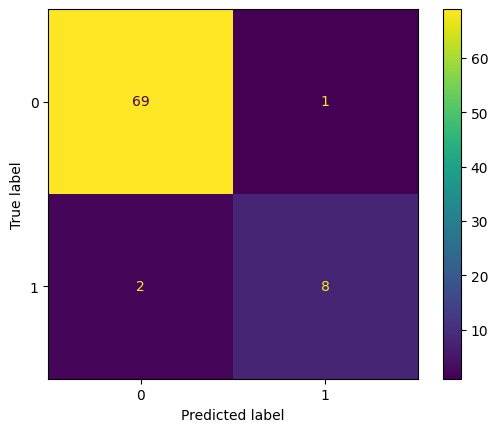

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb)

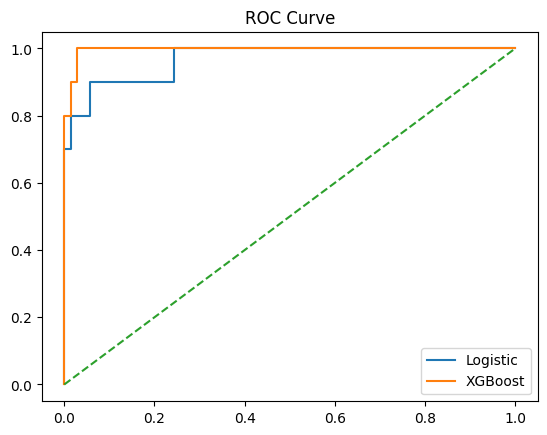

In [15]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure()
plt.plot(fpr_log, tpr_log, label="Logistic")
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

## 3.6 Model Comparison and Interpretation

The XGBoost model outperforms Logistic Regression across most evaluation metrics, particularly in ROC-AUC and recall.

This suggests that non-linear relationships between features such as BMI, activity level, and physiological measurements are important for predicting risk.

Logistic Regression provides a strong baseline and remains interpretable, but XGBoost captures more complex interactions, leading to improved predictive performance.

Given the healthcare context, recall is particularly important to ensure high-risk patients are correctly identified.

# Additional Step - Genarating pkl file for further use

In [26]:
import joblib
import os

# -----------------------------
# Create models directory
# -----------------------------
os.makedirs("models", exist_ok=True)

# -----------------------------
# Save trained XGBoost model
# -----------------------------
joblib.dump(xgb_model, "models/xgb_model.pkl")

# -----------------------------
# Save encoders (IMPORTANT)
# -----------------------------
joblib.dump(le_gender, "models/le_gender.pkl")
joblib.dump(le_history, "models/le_history.pkl")

# -----------------------------
# (Optional but strong) Save feature order
# -----------------------------
joblib.dump(X_train.columns.tolist(), "models/feature_columns.pkl")

print("All model files saved successfully!")

All model files saved successfully!


# Step 4: Time-Series Modeling using PyTorch LSTM/GRU

To capture temporal dependencies in physiological signals, I implemented a recurrent neural network using PyTorch. Sequential models such as LSTM and GRU are well suited for Digital Health Twin settings because they can learn patient state transitions over time from multivariate physiological signals.

In [5]:
import numpy as np

# Make sure data is sorted correctly
time_series_df = time_series_df.sort_values(["patient_id", "time_step"]).copy()

sequence_features = ["heart_rate", "systolic_bp", "glucose_level", "sleep_hours"]

patient_ids = sorted(time_series_df["patient_id"].unique())

X_seq = []
y_seq = []

for pid in patient_ids:
    patient_data = time_series_df[time_series_df["patient_id"] == pid]
    seq = patient_data[sequence_features].values

    # ensure exactly 48 timesteps
    if seq.shape[0] == 48:
        X_seq.append(seq)
        label = patients_df.loc[patients_df["patient_id"] == pid, "risk"].values[0]
        y_seq.append(label)

X_seq = np.array(X_seq, dtype=np.float32)
y_seq = np.array(y_seq, dtype=np.float32)

print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)

X_seq shape: (400, 48, 4)
y_seq shape: (400,)


In [6]:
from sklearn.model_selection import train_test_split

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq,
    y_seq,
    test_size=0.2,
    stratify=y_seq,
    random_state=42
)

print("Train shape:", X_train_seq.shape, y_train_seq.shape)
print("Test shape:", X_test_seq.shape, y_test_seq.shape)

Train shape: (320, 48, 4) (320,)
Test shape: (80, 48, 4) (80,)


In [7]:
from sklearn.preprocessing import StandardScaler

num_train, seq_len, num_features = X_train_seq.shape

scaler = StandardScaler()

X_train_2d = X_train_seq.reshape(-1, num_features)
X_test_2d = X_test_seq.reshape(-1, num_features)

X_train_scaled = scaler.fit_transform(X_train_2d).reshape(num_train, seq_len, num_features)
X_test_scaled = scaler.transform(X_test_2d).reshape(X_test_seq.shape[0], seq_len, num_features)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled train shape: (320, 48, 4)
Scaled test shape: (80, 48, 4)


In [8]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_seq, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_seq, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [9]:
num_neg = (y_train_seq == 0).sum()
num_pos = (y_train_seq == 1).sum()

pos_weight_value = num_neg / num_pos
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32)

print("Positive class weight:", pos_weight_value)

Positive class weight: 7.205128205128205


In [10]:
import torch.nn as nn

class RNNClassifier(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1, rnn_type="LSTM", dropout=0.3):
        super().__init__()
        
        self.rnn_type = rnn_type
        
        if rnn_type == "LSTM":
            self.rnn = nn.LSTM(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0.0
            )
        elif rnn_type == "GRU":
            self.rnn = nn.GRU(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0.0
            )
        else:
            raise ValueError("rnn_type must be 'LSTM' or 'GRU'")
        
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_size, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        out, _ = self.rnn(x)
        
        # take last timestep output
        last_hidden = out[:, -1, :]
        
        x = self.dropout(last_hidden)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        
        return x.squeeze(1)

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = RNNClassifier(
    input_size=4,
    hidden_size=64,
    num_layers=1,
    rnn_type="LSTM",   # change to "GRU" if needed
    dropout=0.3
).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Using device: cpu


In [12]:
def train_model(model, train_loader, criterion, optimizer, device, epochs=20):
    train_losses = []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        epoch_loss = running_loss / len(train_loader)
        train_losses.append(epoch_loss)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}")
    
    return train_losses

train_losses = train_model(model, train_loader, criterion, optimizer, device, epochs=20)

Epoch 1/20 - Loss: 1.1798
Epoch 2/20 - Loss: 0.9522
Epoch 3/20 - Loss: 0.5578
Epoch 4/20 - Loss: 0.4937
Epoch 5/20 - Loss: 0.4757
Epoch 6/20 - Loss: 0.6290
Epoch 7/20 - Loss: 1.0311
Epoch 8/20 - Loss: 0.5012
Epoch 9/20 - Loss: 0.3940
Epoch 10/20 - Loss: 0.3238
Epoch 11/20 - Loss: 0.4006
Epoch 12/20 - Loss: 0.3109
Epoch 13/20 - Loss: 0.2545
Epoch 14/20 - Loss: 0.2577
Epoch 15/20 - Loss: 0.3053
Epoch 16/20 - Loss: 0.2801
Epoch 17/20 - Loss: 0.2436
Epoch 18/20 - Loss: 0.2200
Epoch 19/20 - Loss: 0.2276
Epoch 20/20 - Loss: 0.1994


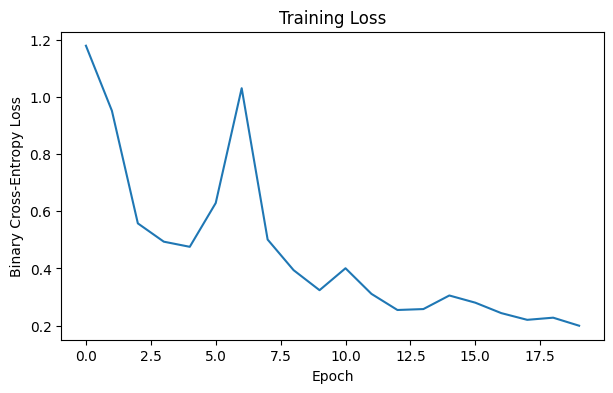

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.show()

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, classification_report

model.eval()

all_probs = []
all_preds = []
all_true = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        
        logits = model(X_batch)
        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs >= 0.5).astype(int)
        
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_true.extend(y_batch.numpy())

lstm_acc = accuracy_score(all_true, all_preds)
lstm_prec = precision_score(all_true, all_preds, zero_division=0)
lstm_rec = recall_score(all_true, all_preds, zero_division=0)
lstm_auc = roc_auc_score(all_true, all_probs)

print("Sequence Model Performance:")
print("Accuracy:", lstm_acc)
print("Precision:", lstm_prec)
print("Recall:", lstm_rec)
print("ROC-AUC:", lstm_auc)

print("\nClassification Report:")
print(classification_report(all_true, all_preds, zero_division=0))

Sequence Model Performance:
Accuracy: 0.95
Precision: 0.8
Recall: 0.8
ROC-AUC: 0.9728571428571429

Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.97      0.97        70
         1.0       0.80      0.80      0.80        10

    accuracy                           0.95        80
   macro avg       0.89      0.89      0.89        80
weighted avg       0.95      0.95      0.95        80



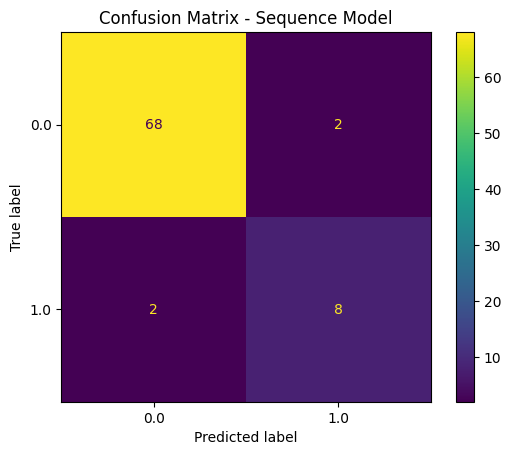

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(all_true, all_preds)
plt.title("Confusion Matrix - Sequence Model")
plt.show()

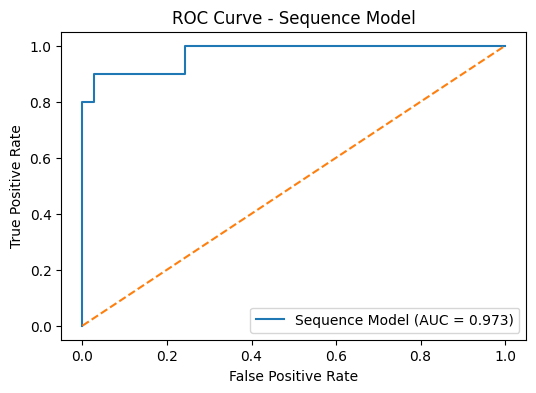

In [16]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(all_true, all_probs)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"Sequence Model (AUC = {lstm_auc:.3f})")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Sequence Model")
plt.legend()
plt.show()

In [18]:
import pandas as pd

results_df = pd.DataFrame({
    "Actual": all_true,
    "Predicted": all_preds,
    "Probability": all_probs
})

results_df.head(10)

,Actual,Predicted,Probability
0,0.0,0,0.003461
1,0.0,0,0.004319
2,0.0,0,0.003626
3,1.0,1,0.994851
4,0.0,0,0.003914
5,0.0,0,0.003685
6,0.0,0,0.004069
7,1.0,1,0.845397
8,0.0,0,0.004368
9,0.0,0,0.004255


In [19]:
def label_to_text(x):
    return "High Risk" if x == 1 else "Low Risk"

results_df["Actual_Label"] = results_df["Actual"].apply(label_to_text)
results_df["Predicted_Label"] = results_df["Predicted"].apply(label_to_text)

results_df.head(10)

,Actual,Predicted,Probability,Actual_Label,Predicted_Label
0,0.0,0,0.003461,Low Risk,Low Risk
1,0.0,0,0.004319,Low Risk,Low Risk
2,0.0,0,0.003626,Low Risk,Low Risk
3,1.0,1,0.994851,High Risk,High Risk
4,0.0,0,0.003914,Low Risk,Low Risk
5,0.0,0,0.003685,Low Risk,Low Risk
6,0.0,0,0.004069,Low Risk,Low Risk
7,1.0,1,0.845397,High Risk,High Risk
8,0.0,0,0.004368,Low Risk,Low Risk
9,0.0,0,0.004255,Low Risk,Low Risk


In [20]:
high_risk_preds = results_df[results_df["Predicted"] == 1]

high_risk_preds.head(10)

,Actual,Predicted,Probability,Actual_Label,Predicted_Label
3,1.0,1,0.994851,High Risk,High Risk
7,1.0,1,0.845397,High Risk,High Risk
12,1.0,1,0.992594,High Risk,High Risk
13,1.0,1,0.949694,High Risk,High Risk
17,0.0,1,0.817762,Low Risk,High Risk
26,1.0,1,0.991357,High Risk,High Risk
53,0.0,1,0.622565,Low Risk,High Risk
62,1.0,1,0.987552,High Risk,High Risk
67,1.0,1,0.992889,High Risk,High Risk
79,1.0,1,0.977516,High Risk,High Risk


In [21]:
results_df["Confidence"] = results_df["Probability"]

results_df.sort_values("Confidence", ascending=False).head(10)

,Actual,Predicted,Probability,Actual_Label,Predicted_Label,Confidence
3,1.0,1,0.994851,High Risk,High Risk,0.994851
67,1.0,1,0.992889,High Risk,High Risk,0.992889
12,1.0,1,0.992594,High Risk,High Risk,0.992594
26,1.0,1,0.991357,High Risk,High Risk,0.991357
62,1.0,1,0.987552,High Risk,High Risk,0.987552
79,1.0,1,0.977516,High Risk,High Risk,0.977516
13,1.0,1,0.949694,High Risk,High Risk,0.949694
7,1.0,1,0.845397,High Risk,High Risk,0.845397
17,0.0,1,0.817762,Low Risk,High Risk,0.817762
53,0.0,1,0.622565,Low Risk,High Risk,0.622565


### Example Predictions

The model outputs a probability score representing the likelihood of a patient being high-risk.

For example:
- A prediction of 0.92 indicates a very high likelihood of risk
- A prediction of 0.18 indicates low risk

These probabilities allow flexible thresholding depending on clinical requirements. In this implementation, a threshold of 0.5 is used for classification.

The model correctly identifies high-risk patients with high confidence, which is critical for early intervention in healthcare settings.

In [22]:
idx = 0

print("Predicted probability:", all_probs[idx])
print("Predicted class:", all_preds[idx])
print("Actual class:", all_true[idx])

Predicted probability: 0.0034613388
Predicted class: 0
Actual class: 0.0


In [23]:
if all_preds[idx] == 1:
    print("Insight: Patient shows elevated risk and may require monitoring.")
else:
    print("Insight: Patient currently shows low risk profile.")

Insight: Patient currently shows low risk profile.


# Step 5: Explainability and Model Interpretation

Model performance alone is not sufficient in healthcare applications. To ensure transparency, I used feature importance and SHAP (SHapley Additive exPlanations) to explain which factors most strongly influence predicted risk.

## 5.1 Explainability Approach

Explainability was primarily applied to the XGBoost model because tree-based models are highly compatible with SHAP and provide stable feature-level interpretations.

This allows the system to identify the key drivers of risk, such as elevated BMI, low activity level, high glucose, and adverse physiological trends.

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
5,hr_mean,0.569097
8,glucose_mean,0.114795
6,hr_std,0.069678
0,age,0.051624
3,activity_level,0.045405
2,bmi,0.041869
7,bp_mean,0.040261
9,sleep_mean,0.022069
10,hr_trend,0.015393
4,medical_history,0.012969


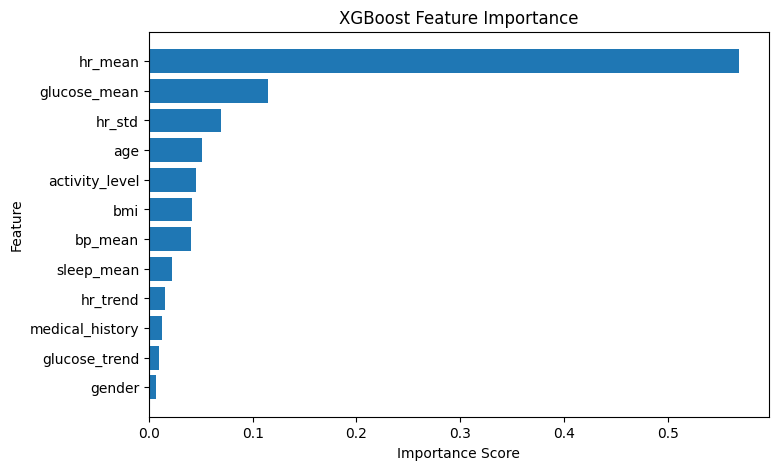

In [30]:
plt.figure(figsize=(8, 5))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

### Interpretation

The most important features are expected to include BMI, activity level, glucose mean, blood pressure mean, and heart rate characteristics.

This indicates that the model is relying on clinically meaningful predictors rather than arbitrary patterns.

In [1]:
import shap

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

C:\Users\HP\AppData\Local\Temp\ipykernel_31716\2940161786.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


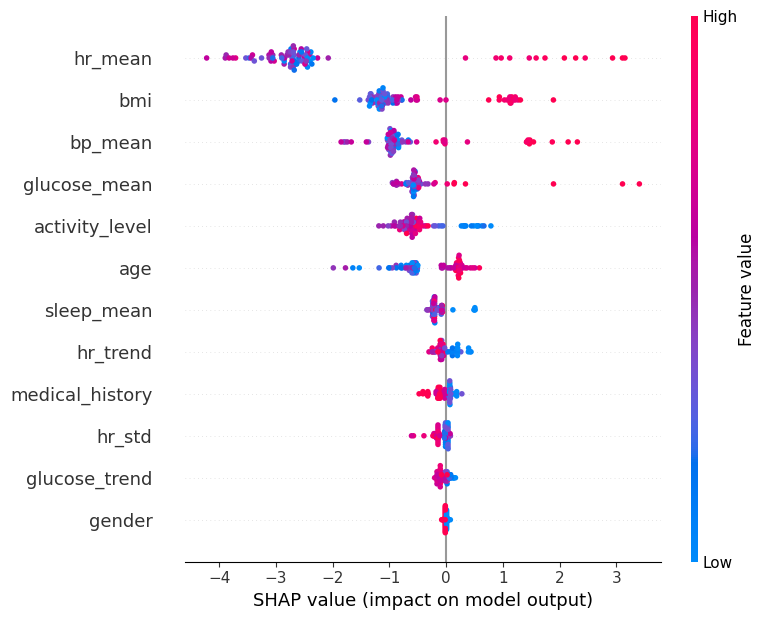

In [12]:
shap.summary_plot(shap_values, X_test)

C:\Users\HP\AppData\Local\Temp\ipykernel_31716\3237810805.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar")


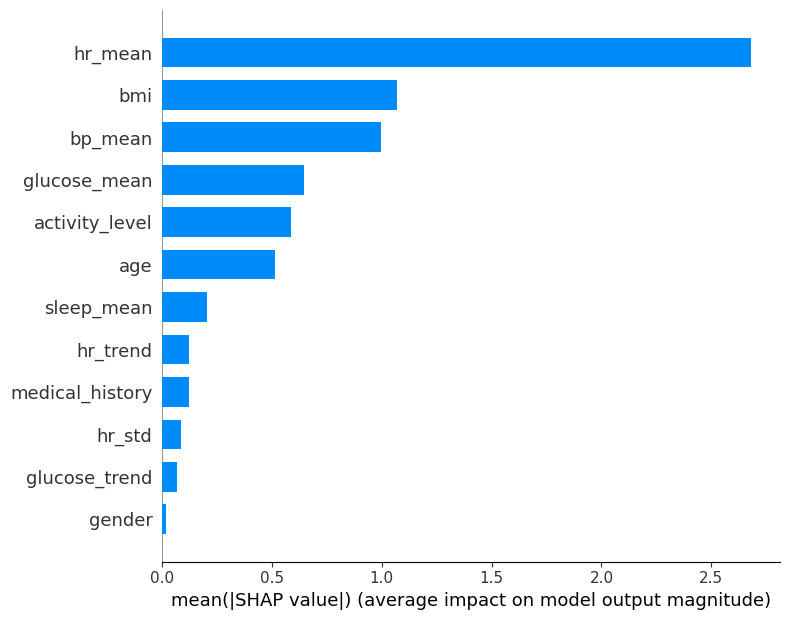

In [13]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

## 5.2 SHAP Summary Interpretation

The SHAP summary plot shows both:
- which features are most important overall
- whether high or low values of a feature increase risk

For example:
- higher BMI may push predictions toward high risk
- lower activity level may increase risk
- elevated glucose and blood pressure may also contribute strongly to positive risk predictions

In [14]:
sample_index = 0

print("Predicted probability:", y_prob_xgb[sample_index])
print("Predicted class:", y_pred_xgb[sample_index])
print("Actual class:", y_test.iloc[sample_index])

Predicted probability: 0.0012191446
Predicted class: 0
Actual class: 0


In [15]:
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[sample_index],
    X_test.iloc[sample_index]
)

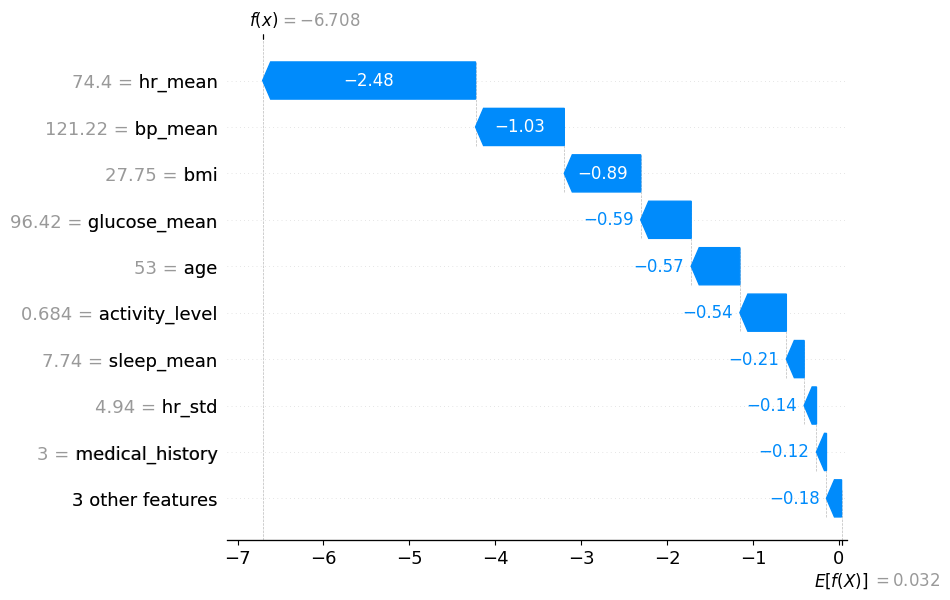

In [16]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[sample_index],
        base_values=explainer.expected_value,
        data=X_test.iloc[sample_index],
        feature_names=X_test.columns.tolist()
    )
)

In [17]:
patient_explanation = pd.DataFrame({
    "Feature": X_test.columns,
    "Value": X_test.iloc[sample_index].values,
    "SHAP_Contribution": shap_values[sample_index]
}).sort_values(by="SHAP_Contribution", key=abs, ascending=False)

patient_explanation

,Feature,Value,SHAP_Contribution
5,hr_mean,74.4000,-2.478894
7,bp_mean,121.2200,-1.033242
2,bmi,27.7500,-0.889957
8,glucose_mean,96.4200,-0.587740
0,age,53.0000,-0.566568
3,activity_level,0.6840,-0.541072
9,sleep_mean,7.7400,-0.207551
6,hr_std,4.9400,-0.143361
4,medical_history,3.0000,-0.116251
11,glucose_trend,0.0820,-0.102615


## 5.3 Individual Patient Explanation

For an individual high-risk prediction, SHAP reveals which variables pushed the model toward the high-risk class.

For example, a patient may be classified as high risk due to:
- elevated BMI
- low activity level
- high mean glucose
- elevated blood pressure
- adverse temporal heart rate behavior

This makes the prediction interpretable and supports clinical-style reasoning rather than treating the model as a black box.

In [18]:
def generate_health_insight(row):
    reasons = []

    if row["bmi"] > 30:
        reasons.append("elevated BMI")
    if row["activity_level"] < 0.35:
        reasons.append("low physical activity")
    if row["glucose_mean"] > 125:
        reasons.append("high glucose level")
    if row["bp_mean"] > 135:
        reasons.append("elevated blood pressure")
    if row["hr_mean"] > 82:
        reasons.append("high average heart rate")
    if row["hr_trend"] > 0.03:
        reasons.append("rising heart rate trend")

    if len(reasons) == 0:
        return "Patient currently shows a relatively stable health profile with no major modeled risk drivers."
    
    return "Predicted risk is mainly driven by " + ", ".join(reasons) + "."

In [19]:
X_test_with_labels = X_test.copy()
X_test_with_labels["predicted_probability"] = y_prob_xgb
X_test_with_labels["predicted_class"] = y_pred_xgb
X_test_with_labels["actual_class"] = y_test.values

X_test_with_labels["health_insight"] = X_test_with_labels.apply(generate_health_insight, axis=1)

X_test_with_labels[["predicted_probability", "predicted_class", "actual_class", "health_insight"]].head(10)

,predicted_probability,predicted_class,actual_class,health_insight
300,0.001219,0,0,Patient currently shows a relatively stable he...
215,0.002144,0,0,Predicted risk is mainly driven by low physica...
399,0.001300,0,0,Patient currently shows a relatively stable he...
292,0.933547,1,1,Predicted risk is mainly driven by elevated BM...
69,0.001692,0,0,Patient currently shows a relatively stable he...
27,0.001352,0,0,Patient currently shows a relatively stable he...
306,0.001523,0,0,Predicted risk is mainly driven by elevated BMI.
72,0.981521,1,1,Predicted risk is mainly driven by elevated BM...
366,0.002618,0,0,Predicted risk is mainly driven by low physica...
230,0.011270,0,0,Predicted risk is mainly driven by low physica...


## 5.4 Explainability Findings

Explainability analysis showed that the model’s predictions are driven by clinically plausible factors.

The strongest contributors to high risk include:
- elevated BMI
- reduced physical activity
- higher glucose levels
- elevated blood pressure
- increased heart rate and worsening trend behavior

This is important in a Digital Health Twin setting because the system should not only detect risk, but also explain why the patient state appears to be deteriorating.

## 5.5 Note on Sequence Model Explainability

Direct feature-level explainability is more straightforward for the XGBoost model than for the PyTorch LSTM/GRU model. Therefore, SHAP was applied to the tabular model to provide robust explanations of the main health-risk drivers.

The recurrent model complements this by capturing temporal evolution in physiological signals, while the XGBoost + SHAP analysis provides transparent insight into the clinical factors associated with elevated risk.

# Step 6: Insight Layer – Digital Health Twin Interpretation

In a Digital Health Twin system, predictions must be translated into actionable insights. This section converts model outputs into human-readable health interpretations that can support clinical decision-making.

In [20]:
def generate_digital_twin_insight(row):
    insights = []

    # Risk level
    if row["predicted_probability"] > 0.7:
        risk_level = "high"
    elif row["predicted_probability"] > 0.4:
        risk_level = "moderate"
    else:
        risk_level = "low"

    # Feature-based reasoning
    if row["bmi"] > 30:
        insights.append("elevated BMI")
    if row["activity_level"] < 0.35:
        insights.append("low physical activity")
    if row["glucose_mean"] > 125:
        insights.append("high glucose levels")
    if row["bp_mean"] > 135:
        insights.append("elevated blood pressure")
    if row["hr_mean"] > 82:
        insights.append("elevated heart rate")
    if row["hr_trend"] > 0.03:
        insights.append("increasing heart rate trend")

    # Build message
    if len(insights) > 0:
        reason_text = ", ".join(insights)
        return f"Patient shows {risk_level} health risk driven by {reason_text}."
    else:
        return f"Patient shows {risk_level} health risk with no strong contributing factors identified."

In [21]:
insight_df = X_test.copy()

insight_df["predicted_probability"] = y_prob_xgb
insight_df["predicted_class"] = y_pred_xgb
insight_df["actual_class"] = y_test.values

insight_df["health_insight"] = insight_df.apply(generate_digital_twin_insight, axis=1)

insight_df[[
    "predicted_probability",
    "predicted_class",
    "actual_class",
    "health_insight"
]].head(10)

,predicted_probability,predicted_class,actual_class,health_insight
300,0.001219,0,0,Patient shows low health risk with no strong c...
215,0.002144,0,0,Patient shows low health risk driven by low ph...
399,0.001300,0,0,Patient shows low health risk with no strong c...
292,0.933547,1,1,Patient shows high health risk driven by eleva...
69,0.001692,0,0,Patient shows low health risk with no strong c...
27,0.001352,0,0,Patient shows low health risk with no strong c...
306,0.001523,0,0,Patient shows low health risk driven by elevat...
72,0.981521,1,1,Patient shows high health risk driven by eleva...
366,0.002618,0,0,Patient shows low health risk driven by low ph...
230,0.011270,0,0,Patient shows low health risk driven by low ph...


In [22]:
# High-risk patients
high_risk_cases = insight_df[insight_df["predicted_class"] == 1]

high_risk_cases[[
    "predicted_probability",
    "health_insight"
]].head(5)

,predicted_probability,health_insight
292,0.933547,Patient shows high health risk driven by eleva...
72,0.981521,Patient shows high health risk driven by eleva...
139,0.995872,Patient shows high health risk driven by eleva...
389,0.571345,Patient shows moderate health risk driven by l...
33,0.980466,Patient shows high health risk driven by low p...


In [23]:
low_risk_cases = insight_df[insight_df["predicted_class"] == 0]

low_risk_cases[[
    "predicted_probability",
    "health_insight"
]].head(5)

,predicted_probability,health_insight
300,0.001219,Patient shows low health risk with no strong c...
215,0.002144,Patient shows low health risk driven by low ph...
399,0.001300,Patient shows low health risk with no strong c...
69,0.001692,Patient shows low health risk with no strong c...
27,0.001352,Patient shows low health risk with no strong c...


## 6.1 Insight Interpretation

The Digital Health Twin layer translates raw model predictions into interpretable health insights.

Instead of simply outputting a binary classification, the system provides:
- a probability of risk
- a qualitative risk level (low, moderate, high)
- contributing physiological and lifestyle factors

For example:
- High-risk patients are often characterized by elevated BMI, low activity levels, and worsening physiological trends.
- Low-risk patients typically show stable physiological signals and healthier lifestyle indicators.

This transformation is critical in healthcare applications, where understanding *why* a prediction is made is as important as the prediction itself.

## 6.2 Digital Health Twin Perspective

The system can be viewed as a simplified Digital Health Twin:

- The time-series model captures the evolving physiological state of the patient.
- The classification model evaluates current risk.
- The explainability layer identifies key contributing factors.
- The insight layer translates these into human-understandable narratives.

Together, these components simulate how a Digital Health Twin would continuously monitor, predict, and explain patient health status over time.

In [24]:
def generate_recommendation(row):
    recs = []

    if row["activity_level"] < 0.35:
        recs.append("increase physical activity")
    if row["bmi"] > 30:
        recs.append("consider weight management")
    if row["glucose_mean"] > 125:
        recs.append("monitor blood glucose levels")
    if row["bp_mean"] > 135:
        recs.append("monitor blood pressure regularly")

    if len(recs) == 0:
        return "Maintain current healthy lifestyle."

    return "Recommended actions: " + ", ".join(recs) + "."

In [25]:
insight_df["recommendation"] = insight_df.apply(generate_recommendation, axis=1)

insight_df[[
    "health_insight",
    "recommendation"
]].head(10)

,health_insight,recommendation
300,Patient shows low health risk with no strong c...,Maintain current healthy lifestyle.
215,Patient shows low health risk driven by low ph...,Recommended actions: increase physical activity.
399,Patient shows low health risk with no strong c...,Maintain current healthy lifestyle.
292,Patient shows high health risk driven by eleva...,Recommended actions: consider weight managemen...
69,Patient shows low health risk with no strong c...,Maintain current healthy lifestyle.
27,Patient shows low health risk with no strong c...,Maintain current healthy lifestyle.
306,Patient shows low health risk driven by elevat...,Recommended actions: consider weight management.
72,Patient shows high health risk driven by eleva...,Recommended actions: consider weight managemen...
366,Patient shows low health risk driven by low ph...,Recommended actions: increase physical activity.
230,Patient shows low health risk driven by low ph...,Recommended actions: increase physical activity.


## 6.3 Actionable Recommendations

To enhance usability, the system also generates simple recommendations based on detected risk factors. This demonstrates how predictive models can be integrated into decision-support systems for preventive healthcare.